# Meta Prompting with LangGraph

## Theory

**Meta prompting** uses an LLM to *design, test, and refine prompts automatically*.
Instead of a human writing prompts by hand through trial and error,
the model reasons about what makes a good prompt, generates one, tests it,
scores the output, and rewrites the prompt based on what went wrong.

### The key insight
LLMs know a lot about what makes prompts effective — they have processed
millions of examples of good and bad instructions. Meta prompting
exploits this knowledge to automate prompt engineering.

### Three roles in a meta prompting system

| Role | Job | LLM call |
|---|---|---|
| Prompt generator | Writes a candidate prompt from the goal description | LLM 1 |
| Task executor | Runs that prompt against real test inputs | LLM 2 |
| Evaluator | Scores the outputs and identifies specific weaknesses | LLM 3 |
| Prompt refiner | Uses the critique to rewrite the prompt | LLM 1 again |

### What meta prompting is NOT
- It is not asking the model to answer a question better
- It is not few-shot prompting (adding examples)
- It is not chain-of-thought (asking the model to reason step by step)
- It IS automated prompt engineering — the *instruction itself* is the thing being optimised

### LangGraph flow
```
goal + test_inputs
  → generate_prompt       (write a candidate prompt)
  → execute_prompt        (run it on all test inputs)
  → evaluate_output       (score quality + critique)
  → [score >= 8] → DONE  (publish the winning prompt)
  → [score < 8]  → refine_prompt → execute_prompt → ...loop
```

### Scenario in this notebook
Automatically engineer a prompt for a **customer complaint classifier**
that categorises support emails into: billing / technical / shipping / other.
The system will generate, test, score, and refine the prompt until it achieves
a quality score of 8/10 or exhausts 5 iterations.

**What it does**: The LLM writes its own prompt, tests it, scores the result,
and rewrites it if the score is too low — automatically.

**Scenario**: Auto-generate a prompt that classifies customer emails
into: `billing`, `technical`, `shipping`, `other`

```
task_goal
  → generate_prompt   (LLM writes a candidate prompt)
  → execute_prompt    (run it on a test email)
  → score_output      (LLM scores quality 1–10)
  → score ≥ 7 → DONE
  → score < 7 → refine_prompt → execute_prompt → ...loop
```

In [1]:
from typing import TypedDict, Optional, Literal
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from IPython.display import Image, display
from dotenv import load_dotenv
import json, os

load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

llm = ChatOpenAI(model="gpt-4o", temperature=0.3)

In [2]:
# ── State ─────────────────────────────────────────────────
class MetaState(TypedDict):
    task_goal: str            # What we want the prompt to accomplish
    test_input: str           # A sample input to test the prompt on
    expected_output: str      # The correct answer for the test input
    current_prompt: Optional[str]   # The candidate prompt being tested
    llm_output: Optional[str]       # What the prompt produced
    score: Optional[int]            # Quality score 1–10
    critique: Optional[str]         # What was wrong
    iteration: int                  # How many refinement rounds done
    max_iterations: int             # Safety ceiling
    final_prompt: Optional[str]     # The approved prompt

In [3]:
# ── Node 1: generate_prompt ───────────────────────────────
# The LLM reads the task goal and writes a complete system prompt.
# This is the "meta" step — the model is prompting itself.

def generate_prompt(state: MetaState) -> MetaState:
    print(f"\n[Node 1] Generating prompt (iteration {state['iteration'] + 1})")

    response = llm.invoke([
        SystemMessage(content="You are a prompt engineering expert. "
                               "Write clear, precise system prompts for LLM classification tasks. "
                               "Output ONLY the prompt text. No explanation."),
        HumanMessage(content=f"Write a system prompt for this task:\n{state['task_goal']}\n\n"
                              f"The model must output ONLY a single category word.")
    ])

    prompt = response.content.strip()
    print(f"[Node 1] Prompt generated ({len(prompt)} chars)")
    return {**state, "current_prompt": prompt}

In [4]:
# ── Node 2: execute_prompt ────────────────────────────────
# Run the generated prompt on the test input.
# Uses temp=0.0 for deterministic, repeatable results.

def execute_prompt(state: MetaState) -> MetaState:
    print(f"[Node 2] Running prompt on test input...")

    task_llm = ChatOpenAI(model="gpt-4o", temperature=0.0)

    response = task_llm.invoke([
        SystemMessage(content=state["current_prompt"]),
        HumanMessage(content=state["test_input"])
    ])

    output = response.content.strip().lower().split()[0].rstrip(".,;:")
    print(f"[Node 2] Output: '{output}'  |  Expected: '{state['expected_output']}'")
    return {**state, "llm_output": output}

In [5]:
# ── Node 3: score_output ──────────────────────────────────
# The LLM scores the output quality.
# A structured JSON response gives a clean machine-readable score.

def score_output(state: MetaState) -> MetaState:
    print(f"[Node 3] Scoring output quality...")

    is_correct = state["llm_output"] == state["expected_output"]

    response = llm.invoke([HumanMessage(content=f"""
A prompt was tested on this input:
Input:    {state['test_input']}
Expected: {state['expected_output']}
Got:      {state['llm_output']}
Correct:  {is_correct}

The prompt used:
{state['current_prompt']}

Score this prompt 1-10. Consider: correctness, clarity, output format.
Reply ONLY with JSON (no markdown fences):
{{"score": <int>, "critique": "<one sentence on what to fix>"}}
""")])

    try:
        result = json.loads(response.content.strip())
        score   = int(result["score"])
        critique = result["critique"]
    except (json.JSONDecodeError, KeyError):
        score    = 9 if is_correct else 3
        critique = "Output format issue" if not is_correct else ""

    print(f"[Node 3] Score: {score}/10 — {critique}")
    return {**state, "score": score, "critique": critique}

In [6]:
# ── Node 4: refine_prompt ─────────────────────────────────
# When the score is too low, rewrite the prompt using the critique.
# Targeted fix — not a random rewrite.

def refine_prompt(state: MetaState) -> MetaState:
    print(f"[Node 4] Refining prompt based on critique...")

    response = llm.invoke([
        SystemMessage(content="You are a prompt engineer. Fix the issues described. "
                               "Output ONLY the revised prompt. No explanation."),
        HumanMessage(content=f"Current prompt (has issues):\n{state['current_prompt']}\n\n"
                              f"Critique — what to fix:\n{state['critique']}\n\n"
                              f"Rewrite the prompt to fix these issues exactly.")
    ])

    refined = response.content.strip()
    print(f"[Node 4] Refined prompt ready")
    return {
        **state,
        "current_prompt": refined,
        "iteration": state["iteration"] + 1
    }

In [7]:
# ── Router ────────────────────────────────────────────────
SCORE_THRESHOLD = 7

def should_refine(state: MetaState) -> Literal["refine_prompt", "__end__"]:
    if state["iteration"] >= state["max_iterations"]:
        print(f"[Router] Max iterations reached — accepting prompt")
        return "__end__"
    if state["score"] >= SCORE_THRESHOLD:
        print(f"[Router] Score {state['score']}/10 — ACCEPTED")
        return "__end__"
    print(f"[Router] Score {state['score']}/10 — REFINING")
    return "refine_prompt"

In [8]:
# ── Save final prompt node ────────────────────────────────
def save_final(state: MetaState) -> MetaState:
    print(f"\n[Done] Final score: {state['score']}/10 after {state['iteration']+1} iteration(s)")
    return {**state, "final_prompt": state["current_prompt"]}

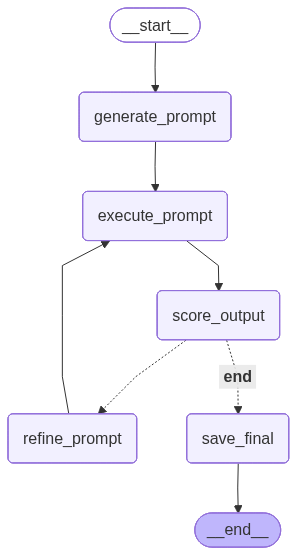

In [9]:
# ── Graph Construction ─────────────────────────────────────
def build_meta_graph():
    builder = StateGraph(MetaState)

    builder.add_node("generate_prompt", generate_prompt)
    builder.add_node("execute_prompt",  execute_prompt)
    builder.add_node("score_output",    score_output)
    builder.add_node("refine_prompt",   refine_prompt)
    builder.add_node("save_final",      save_final)

    # Linear start
    builder.add_edge(START,             "generate_prompt")
    builder.add_edge("generate_prompt", "execute_prompt")
    builder.add_edge("execute_prompt",  "score_output")

    # Quality gate
    builder.add_conditional_edges(
        "score_output",
        should_refine,
        {"refine_prompt": "refine_prompt", "__end__": "save_final"}
    )

    # Refinement loops back to execute (not generate)
    builder.add_edge("refine_prompt", "execute_prompt")
    builder.add_edge("save_final",    END)

    return builder.compile()


graph = build_meta_graph()
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
# ── Run ────────────────────────────────────────────────────
result = graph.invoke({
    "task_goal": (
        "Classify customer support emails into one of four categories: "
        "billing (payments, invoices, refunds), "
        "technical (bugs, errors, login issues), "
        "shipping (delivery, tracking, damaged items), "
        "other (general questions). "
        "Output ONLY the single category word."
    ),
    "test_input":      "I was charged twice for my subscription this month.",
    "expected_output": "billing",
    "current_prompt":  None,
    "llm_output":      None,
    "score":           None,
    "critique":        None,
    "iteration":       0,
    "max_iterations":  3,
    "final_prompt":    None,
})

print("\n" + "="*60)
print("WINNING PROMPT:")
print("="*60)
print(result["final_prompt"])
print(f"\nFinal score : {result['score']}/10")
print(f"Iterations  : {result['iteration'] + 1}")
print(f"Test output : '{result['llm_output']}' (expected '{result['expected_output']}')") 


[Node 1] Generating prompt (iteration 1)
[Node 1] Prompt generated (161 chars)
[Node 2] Running prompt on test input...
[Node 2] Output: 'billing'  |  Expected: 'billing'
[Node 3] Scoring output quality...
[Node 3] Score: 10/10 — The prompt is clear, concise, and correctly classifies the input into the expected category with the correct output format.
[Router] Score 10/10 — ACCEPTED

[Done] Final score: 10/10 after 1 iteration(s)

WINNING PROMPT:
Classify the following customer support email into one of the following categories: billing, technical, shipping, or other. Output ONLY the single category word.

Final score : 10/10
Iterations  : 1
Test output : 'billing' (expected 'billing')


In [11]:
# ── Use the final prompt in production ────────────────────
# The winning prompt is now ready to deploy as a system message.

task_llm = ChatOpenAI(model="gpt-4o", temperature=0.0)

test_emails = [
    "My package has been stuck in transit for 5 days.",
    "The app keeps crashing when I open the dashboard.",
    "Can you explain the difference between your plans?",
]

print("PRODUCTION TEST WITH WINNING PROMPT")
print("-" * 40)
for email in test_emails:
    r = task_llm.invoke([
        SystemMessage(content=result["final_prompt"]),
        HumanMessage(content=email)
    ])
    category = r.content.strip().lower().split()[0].rstrip(".,;:")
    print(f"{category:12} | {email}")

PRODUCTION TEST WITH WINNING PROMPT
----------------------------------------
shipping     | My package has been stuck in transit for 5 days.
technical    | The app keeps crashing when I open the dashboard.
other        | Can you explain the difference between your plans?


## What each node does

| Node | Job | Key point |
|---|---|---|
| `generate_prompt` | LLM writes a prompt from the task goal | The model is engineering its own instruction |
| `execute_prompt` | Runs the prompt on a test input | `temp=0.0` for deterministic, comparable results |
| `score_output` | LLM scores quality and writes a critique | JSON output → machine-readable score |
| `refine_prompt` | Rewrites prompt using the critique | Targeted fix — not a random rewrite |
| `save_final` | Saves the approved prompt | Ready to use as a system message in production |

## Why refinement loops to `execute_prompt`, not `generate_prompt`

After `refine_prompt` we test the *improved* prompt — not start fresh.
Going back to `generate_prompt` would discard the refinement.
The loop is: **refine → execute → score → refine** — not regenerate.